In [1]:
import pandas as pd
import copy
consultants = pd.read_csv("consultants.csv").to_dict("records")

In [2]:

consultants_copy = copy.deepcopy(consultants)

for i in range(100):
    consultants_copy[i]['Sum_of_skills'] = consultants_copy[i]["analytics_expertise"] + consultants_copy[i]["functional_expertise"] + consultants_copy[i]["domain_expertise"] + consultants_copy[i]["communication_skill"]
    consultants_copy[i]['status'] = 'Not Assigned'

j=0
for i in range(100):
    j = j+ consultants_copy[i]["Sum_of_skills"]


print("The sum of total skillsets :" , j)
print ("The objective is to allocate consultants to each team so that on an average each team skillset should be around:", round(j/20))  





The sum of total skillsets : 141
The objective is to allocate consultants to each team so that on an average each team skillset should be around: 7


## Algorithm

In [3]:
## Initializing the team and total score variables
    
t1 =[]
t2 =[]
t3 =[]
t4 =[]
t5 =[]
t6 =[]
t7 =[]
t8 =[]
t9 =[]
t10 =[]
t11 =[]
t12 =[]
t13 =[]
t14 =[]
t15 =[]
t16 =[]
t17 =[]
t18 =[]
t19 =[]
t20 =[]
teams = [t1, t2, t3, t4, t5,t6, t7, t8, t9, t10, t11, t12, t13, t14, t15, t16, t17, t18, t19,t20]

ts1 = 0
ts2 = 0
ts3 = 0
ts4 = 0
ts5 = 0
ts6 = 0
ts7 = 0
ts8 = 0
ts9 = 0
ts10 = 0
ts11 = 0
ts12 = 0
ts13 = 0
ts14 = 0
ts15 = 0
ts16 = 0
ts17 = 0
ts18 = 0
ts19 = 0
ts20 = 0

tot_team_score = [ts1,ts2,ts3,ts4,ts5,ts6,ts7,ts8,ts9,ts10,ts11,ts12,ts13,ts14,ts15,ts16,ts17,ts18,ts19,ts20]




In [4]:
## To Allocate 16 consultants with analytics expertise to 16 different teams

i=0

while i <= len(teams):
    analytic_expertise = False
    for x in range(len(consultants_copy)):
        
        if analytic_expertise == False:
            if consultants_copy[x]["status"] == "Not Assigned":
                if consultants_copy[x]["analytics_expertise"] == 1:
                    teams[i].append(consultants_copy[x]["consultant_id"])
                    tot_team_score[i] += consultants_copy[x]["Sum_of_skills"]
                    analytic_expertise = True
                    consultants_copy[x]["status"] = "Assigned"
                    continue

            
    i += 1

    

In [5]:
## To Allocate 16 consultants with NO expertise at all to 16 different teams

i=0

while i <= 16:
    no_expertise = False
    for x in range(len(consultants_copy)):
        
        if no_expertise == False:
            if consultants_copy[x]["status"] == "Not Assigned":
                if consultants_copy[x]["Sum_of_skills"] == 0:
                    if len(teams[i]) !=0:
                        teams[i].append(consultants_copy[x]["consultant_id"])
                        tot_team_score[i] += consultants_copy[x]["Sum_of_skills"]
                        no_expertise = True
                        consultants_copy[x]["status"] = "Assigned"
                        continue

            
    i += 1

    

In [6]:
## To Allocate the remaining 2 consultants with NO expertise at all to one of the 
## existing teams where a consultant's total skill is 4.


team_count = 0

while len(teams[team_count]) <= 5:
    
    for x in range(len(consultants_copy)):
        
        if consultants_copy[x]["status"] == "Not Assigned":
            if consultants_copy[x]["Sum_of_skills"] == 0:
                if len(teams[team_count]) < 5 and tot_team_score[team_count] == 4 :
                    teams[team_count].append(consultants_copy[x]["consultant_id"])
                    tot_team_score[team_count] += consultants_copy[x]["Sum_of_skills"]
                    consultants_copy[x]["status"] = "Assigned"    
                    break
        
    if team_count == 19:
        break
    else:
        team_count += 1

In [7]:
## To allocate the reminaing consultants in each of the 20 teams based on the required total skills of 7 or 8.

count = 0

while len(teams[count]) < 5:
    
    for x in range(len(consultants_copy)):
        consultants_to_be_added = 5 - len(teams[count])
        skills_to_be_added = 7 - tot_team_score[count]
        individual_cons_skill = round(skills_to_be_added/consultants_to_be_added)
        
        if consultants_copy[x]["status"] == "Not Assigned":
            
            if consultants_copy[x]["Sum_of_skills"] == individual_cons_skill: 
                
                if len(teams[count]) < 5:
                    
                    if consultants_copy[x]["functional_expertise"] == 1 or consultants_copy[x]["domain_expertise"] == 1 or consultants_copy[x]["communication_skill"] == 1: 
                        
                        teams[count].append(consultants_copy[x]["consultant_id"])
                        tot_team_score[count] += consultants_copy[x]["Sum_of_skills"]
                        consultants_copy[x]["status"] = "Assigned"  
                        if len(teams[count]) == 5:
                               break
                            

                
    if count == 19:
        break
    else:
        count += 1

In [8]:
for x in range(len(teams)):
     if len(teams[x]) < 5:
            for i in range(len(consultants_copy)):
                consultants_to_be_added = 5 - len(teams[x])
                skills_to_be_added = 7 - tot_team_score[x]
                individual_cons_skill = round(skills_to_be_added/consultants_to_be_added)
                
                if consultants_copy[i]["status"] == "Not Assigned":
                    if consultants_copy[i]["Sum_of_skills"] in range (individual_cons_skill - 1,individual_cons_skill + 2):
                        if len(teams[x]) < 5:
                            teams[x].append(consultants_copy[i]["consultant_id"])
                            tot_team_score[x] += consultants_copy[i]["Sum_of_skills"]
                            consultants_copy[i]["status"] = "Assigned"
                            if len(teams[x]) == 5:
                                break

In [9]:
for x in range(len(consultants_copy)):
    if consultants_copy[x]["status"] == "Not Assigned":
        print(consultants_copy[x]["consultant_id"])
        print(consultants_copy[x]["Sum_of_skills"])

## Output

In [12]:
tot_team_score

[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 7, 7, 7, 7, 7]

In [13]:
data = teams
df = pd.DataFrame(data, columns = ['Member 1', 'Member 2', 'Member 3', 'Member 4', 'Member 5'])

print(df)

         Member 1       Member 2       Member 3       Member 4        Member 5
0    consultant_9  consultant_15   consultant_4   consultant_5   consultant_17
1   consultant_13  consultant_28  consultant_22  consultant_23   consultant_24
2   consultant_16  consultant_29  consultant_25  consultant_32   consultant_37
3   consultant_27  consultant_33  consultant_34  consultant_39   consultant_41
4   consultant_36  consultant_35  consultant_42  consultant_48   consultant_51
5   consultant_40  consultant_38  consultant_52  consultant_57   consultant_58
6   consultant_43  consultant_46   consultant_2  consultant_59   consultant_66
7   consultant_47  consultant_54  consultant_65  consultant_71   consultant_76
8   consultant_49  consultant_56  consultant_77  consultant_79   consultant_80
9   consultant_60  consultant_62  consultant_83  consultant_84   consultant_85
10  consultant_61  consultant_64  consultant_92  consultant_87   consultant_96
11  consultant_63  consultant_70  consultant_94  con

In [14]:
df.to_excel('teams.xlsx')

analytics_expertise	functional_expertise	domain_expertise	communication_skill	SUM
1	3	0	3	7
1	1	1	4	7
1	0	4	2	7
1	1	2	3	7
1	4	0	2	7
1	1	1	4	7
1	3	1	2	7
1	3	1	2	7
1	2	2	2	7
1	3	0	3	7
1	1	2	3	7
1	2	3	1	7
1	1	2	3	7
1	2	2	2	7
1	2	2	3	8
1	3	1	2	7
0	1	3	3	7
0	2	2	3	7
0	1	3	3	7
0	1	2	4	7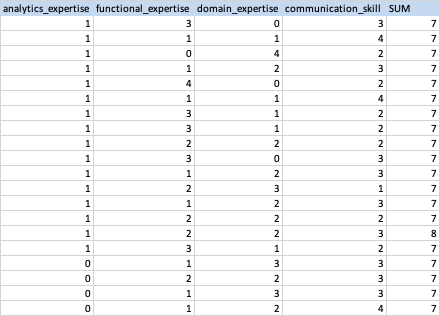